In [111]:
# usual imports in a classic ML pipeline for Regression
# pip install numpy
# pip install pandas
# pip install seaborn
# pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import pipelines, SVM etc.
from sklearn.model_selection import train_test_split
from sklearn import metrics, svm

# regression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# classifier
from sklearn.neighbors import KNeighborsClassifier

<h3>Data Set Link</h3>
<a href="https://www.kaggle.com/datasets/mohannapd/linear-regression-sales-prediction-of-carseats">
    Linear Regression Sales Prediction of Car Seats Dataset
</a>


<h3>STEP 1 - Load the data </h3>

In [112]:
# load the data
df = pd.read_csv("CarSeats.csv")

# let's quickly see the first 5 rows of data
df.head()


,No,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,1,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,2,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,3,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,4,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,5,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [113]:
# do we have missing values? apparently not
# dataset can't have any missing values when passing the data
# to the machine learning algorithm
df.isna().sum()

No             0
Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

In [114]:
# do we have duplicates?
int(df.duplicated().sum())

0

In [115]:
# drop No field since it is not required
df.drop(columns=['No'], inplace=True)


In [116]:
# Check value counts for ShelveLoc before modifying ordinal categories
df['ShelveLoc'].value_counts()


ShelveLoc
Medium    219
Bad        96
Good       85
Name: count, dtype: int64

In [117]:
# Map ShelveLoc - Ordinal categories
category_mapper = {
'Good': 2,
'Medium': 1,
'Bad': 0
}
df['ShelveLoc'] = df['ShelveLoc'].replace(category_mapper)

df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,Yes,Yes
1,11.22,111,48,16,260,83,2,65,10,Yes,Yes
2,10.06,113,35,10,269,80,1,59,12,Yes,Yes
3,7.40,117,100,4,466,97,1,55,14,Yes,Yes
4,4.15,141,64,3,340,128,0,38,13,Yes,No


In [118]:
from sklearn.preprocessing import LabelEncoder

# list all variables that can be binary-converted
variables = ['Urban', 'US']

# load the encoder
encoder = LabelEncoder()

# convert the listed variables
df[variables] = df[variables].apply(encoder.fit_transform)

df.head()


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,2,65,10,1,1
2,10.06,113,35,10,269,80,1,59,12,1,1
3,7.40,117,100,4,466,97,1,55,14,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0


<h3>Data is good to go (all numbers) => train model etc.</h3>


In [119]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("Sales", axis=1)

# our target variable is y
y = df['Sales']

In [120]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1718951)

Based on iterations, best k-value is this:
7


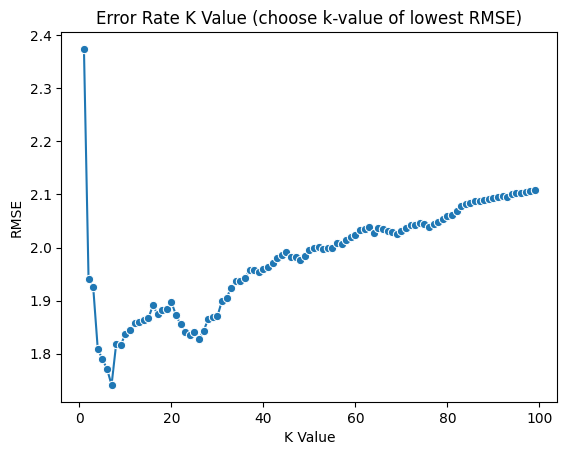

In [121]:
# REGRESSION VERSION
# adjust this to 50 or even 150 if you have lots of data rows
max_iterations = 100

# list to save the error values in the loop
error = []

# the default metric in scikit-learn
metric_selection = "minkowski"
weight_selection = "uniform"
algorithm_selection = "auto"

# Calculating error for K values between 1 and 40
for i in range(1, max_iterations):

    # try with current k-value, train the model and make a test prediction
    knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=i, metric=metric_selection, weights=weight_selection, algorithm=algorithm_selection))
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    
    # save the error value for this k-value
    error.append(np.sqrt(metrics.mean_squared_error(y_test, pred_i)))
    
# plot all the k-values and their error values
sns.lineplot(x=range(1, max_iterations), y=error, marker='o')
plt.title('Error Rate K Value (choose k-value of lowest RMSE)')
plt.xlabel('K Value')
plt.ylabel('RMSE')

# choose best k-value based on metrics
# we have to add +1 to k-value, since argmin() returns an index
# which starts from 0, but k-values start from 1
print("Based on iterations, best k-value is this:")
k_value = np.argmin(error) + 1
print(k_value)

In [122]:
# create the model and train it with the data
# use pipeline to scale the X-values automatically with StandardScaler

# TECHNICALLY you don't even have to use scaler for X (StandardScaler here)
# but it doesn't hurt the model either. it's just more practical
# to have the scaler already implemented in case we try different algorithms on the go
model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k_value, metric=metric_selection))
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('kneighborsregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(7)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to st

In [123]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

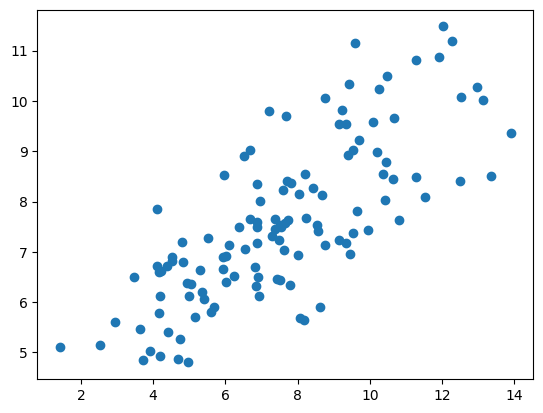

In [124]:
# let's plot how far the predictions are from the real target values (y)
# in the test dataset

# if the values follow a diagonal line (from bottom left to top right)
# => we have good predictions with the model
# we basically compare the predicted values to the actual true values 
# and compare the differences
plt.scatter(y_test, predictions)
plt.show()

In [125]:
# MAE = Mean average error
mae = metrics.mean_absolute_error(y_test, predictions)
print("MAE:")
print(f"{round(mae, 2)} $")

# MSE = Mean squared error
mse = metrics.mean_squared_error(y_test, predictions)
print("\nMSE:")
print(f"{round(mse, 2)} $^2")

# RMSE = Root Mean Squared Error
rmse = np.sqrt(mse)
print("\nRMSE:")
print(f"{round(rmse, 2)} $")

# R-square (or R2) - how well the model describes the original dataset
# 1 => model describes the data perfectly
# 0 => model doesn't describe the data at all
r2 = metrics.r2_score(y_test, predictions)
print("\nR-squared:")
print(f"{round(r2, 2)}")

MAE:
1.37 $

MSE:
3.03 $^2

RMSE:
1.74 $

R-squared:
0.55


C:\Users\Gayani\AppData\Local\Temp\ipykernel_16804\2920752686.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - predictions))


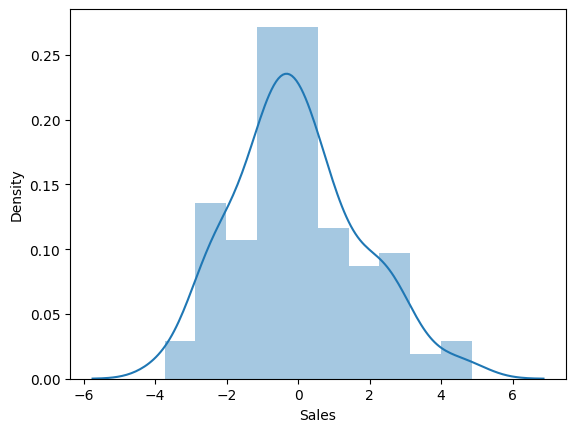

In [126]:
# if the prediction distribution is far from standard normal distritbuion
# then the model is not probably good enough
# distplot is deprecated and will be removed in future seaborn versions
# but not direct replacement has been created so far
sns.distplot((y_test - predictions))
plt.show()
plt.close()

In [127]:
X.columns

Index(['CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='str')

In [128]:
tester_row = {
    'CompPrice': 120,
    'Income': 70,
    'Advertising': 10,
    'Population': 300,
    'Price': 100,
    'ShelveLoc': 2,   # encoded (Bad=0, Medium=1, Good=2)
    'Age': 50,
    'Education': 15,
    'Urban': 1,       # Yes=1, No=0
    'US': 1           # Yes=1, No=0
}

tester_row = pd.DataFrame([tester_row])


In [129]:
# get the output/result from the model
# based on the user's given new data (above code cell)
result = model.predict(tester_row)[0]

print()
print(f"Predicted sales price:")
print(f"$ {round(float(result), 2)}")
print("----------------------------")


Predicted sales price:
$ 10.58
----------------------------
